In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random
import seaborn as sns


In [2]:

# Read the CSV file into a DataFrame
df = pd.read_csv('output_file.csv')
df = df.dropna(axis=1, how='all')
df = df.dropna(thresh=2).reset_index(drop=True)
df.head(30)


,Resultaat,Mineral,Eenheid,Resultaat.1,Streeftraject
0,NaN,N-totale bodemvoorraad,kg N/ha,9990,2650 - 4160
1,Chemisch,C/N-ratio,NaN,14,13 - 17
2,Chemisch,N-leverend vermogen,kg N/ha,145,95 - 145
3,Chemisch,S-totale bodemvoorraad,kg S/ha,1760,630 - 1475
4,Chemisch,C/S-ratio,NaN,79,50 - 75
5,Chemisch,S-leverend vermogen,kg S/ha,22,20 - 30
6,Chemisch,P-plantbeschikbaar,kg P/ha,"2,8","4,6 - 7,7"
7,Chemisch,P-bodemvoorraad,kg P/ha,360,305 - 525
8,Chemisch,K-plantbeschikbaar,kg K/ha,425,180 - 285
9,Chemisch,K-bodemvoorraad,kg K/ha,510,530 - 685


In [3]:
grouped_df = df.groupby('Resultaat', sort=True) 
first_group_name = list(grouped_df.groups.keys())[0]
df['Resultaat'] = df['Resultaat'].fillna(first_group_name)
df.head()


,Resultaat,Mineral,Eenheid,Resultaat.1,Streeftraject
0,Chemisch,N-totale bodemvoorraad,kg N/ha,9990,2650 - 4160
1,Chemisch,C/N-ratio,NaN,14,13 - 17
2,Chemisch,N-leverend vermogen,kg N/ha,145,95 - 145
3,Chemisch,S-totale bodemvoorraad,kg S/ha,1760,630 - 1475
4,Chemisch,C/S-ratio,NaN,79,50 - 75


In [4]:
grouped_df = df.groupby( ['Eenheid'] )
percentage_df = grouped_df.get_group('%')
percentage_df

,Resultaat,Mineral,Eenheid,Resultaat.1,Streeftraject
21,Fysisch,C-organisch,%,"5,4",NaN
22,Fysisch,stof,%,"9,6",NaN
23,Fysisch,Klei (<2 µm),%,19,NaN


In [5]:
percentage_df['Resultaat.1'] = percentage_df['Resultaat.1'].str.replace(',', '.')
percentage_df['Resultaat.1'] = percentage_df['Resultaat.1'].astype(float)


C:\Users\Ashil_rayan\AppData\Local\Temp\ipykernel_6616\218779005.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  percentage_df['Resultaat.1'] = percentage_df['Resultaat.1'].str.replace(',', '.')
C:\Users\Ashil_rayan\AppData\Local\Temp\ipykernel_6616\218779005.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  percentage_df['Resultaat.1'] = percentage_df['Resultaat.1'].astype(float)


C:\Users\Ashil_rayan\AppData\Local\Temp\ipykernel_6616\633763324.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  percentage_df['Cumulative_Percentage'] = percentage_df['Resultaat.1'].cumsum()
C:\Users\Ashil_rayan\AppData\Local\Temp\ipykernel_6616\633763324.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  percentage_df = percentage_df.append({'Mineral': 'Other',


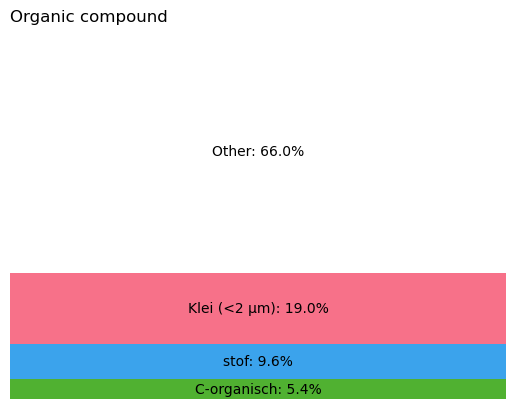

In [6]:
 
# Calculate the cumulative percentage
percentage_df['Cumulative_Percentage'] = percentage_df['Resultaat.1'].cumsum()

# Calculate the remaining percentage
remaining_percentage = 100 - percentage_df['Cumulative_Percentage'].iloc[-1]

# Add 'Other' category with the remaining percentage if applicable
if remaining_percentage > 0:
    percentage_df = percentage_df.append({'Mineral': 'Other',
                    'Resultaat.1': remaining_percentage},
                   ignore_index=True)

num_colors = len(percentage_df) - 1
colors = sns.color_palette('husl', n_colors=num_colors).as_hex()

# Shuffle the colors
random.shuffle(colors)

# Assign white color specifically to 'Other' category
colors.append('white')

# Plot the rectangle box with colored segments and text annotations
fig, ax = plt.subplots() 
x = 0
y = 0
width = 100
height = 100

for i in range(len(percentage_df)):
    percentage = percentage_df['Resultaat.1'].iloc[i]
    color = colors[i]
    rect = Rectangle((x, y), width, (height * percentage) / 100, facecolor=color)
    ax.add_patch(rect)
     
    annotation = f'{percentage_df["Mineral"].iloc[i]}: {percentage}%'
    
    ax.annotate(annotation, xy=(x + width / 2, y + (height * percentage) / 200),
                xytext=(0, 0), textcoords='offset points', ha='center', va='center')
    y += (height * percentage) / 100

ax.set_xlim(0, width)
ax.set_ylim(0, height)
plt.axis('off')  # Hide axis
plt.title('Organic compound', loc='left')
plt.savefig('plot1.png')
plt.show()


In [7]:
 
# Searching for 'pH' in the 'Mineral' column
pH_row = df['Mineral'].str.contains('(pH)' )

# Retrieving the number from the same row where 'pH' is found
pH = df.loc[pH_row, 'Resultaat.1'].values[0] 

pH = pH.replace(',', '.')

# Convert to a numeric value
pH_value = float(pH)

C:\Users\Ashil_rayan\AppData\Local\Temp\ipykernel_6616\189224176.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  pH_row = df['Mineral'].str.contains('(pH)' )


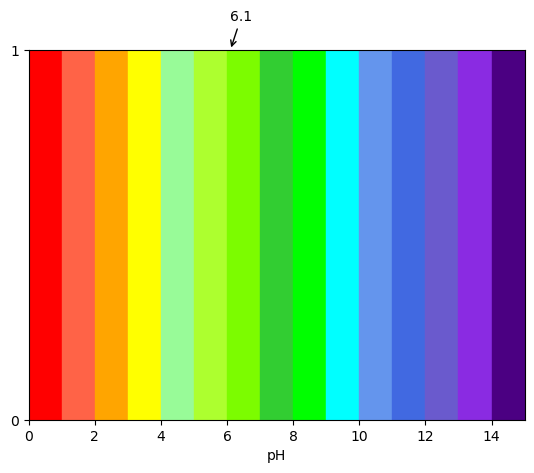

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# pH values and corresponding colors
pH_values = [i for i in range(15)]
colors = ['red', 'tomato', 'orange', 'yellow', 'palegreen', 'greenyellow', 'lawngreen', 'limegreen', 'lime',
          'aqua', 'cornflowerblue', 'royalblue', 'slateblue', 'blueviolet', 'indigo']

# Create a figure and axis
fig, ax = plt.subplots()

# Set the size and position of the rectangle
rect_width = 1
rect_height = 1
rect_x = 0
rect_y = 0

# Iterate over the pH values and colors to draw rectangles
for i in range(len(pH_values)):
    rect_color = colors[i]
    rect = plt.Rectangle((rect_x, rect_y), rect_width, rect_height, color=rect_color)
    ax.add_patch(rect)
    rect_x += rect_width

# Set the x-axis and y-axis limits
ax.set_xlim(0, rect_x)
ax.set_ylim(rect_y, rect_y + rect_height)

# Add an arrow and text annotation for the pH value 
arrow_x = pH_value 
arrow_y = rect_y + rect_height
ax.annotate(str(pH_value), xy=(arrow_x, arrow_y), xytext=(arrow_x, arrow_y + 0.08),
            arrowprops=dict(arrowstyle='->'))


plt.yticks([0,1])

# Add labels 
plt.xlabel('pH')

plt.savefig('plot2.png')
# Show the plot
plt.show()
